## Setup and imports

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
print(PROJECT_ROOT)

/content/drive/MyDrive/Colab Notebooks/AFib-ML-Bias/counterfactual-fairness


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1)

EXP_NAME = "SBS Audit Test"
sbs_audit = pd.read_csv(f'{PROJECT_ROOT}/results/{EXP_NAME}/sps_audit.csv')
sbs_audit_baseline = pd.read_csv(f'{PROJECT_ROOT}/results/{EXP_NAME}/sps_audit_baseline.csv')

# Analysis

### Basics

In [26]:
scorings = sbs_audit.groupby('feature')[['sensitivity_scoring', 'fidelity_scoring']].first()

sbs_results = sbs_audit.drop(['sensitivity_scoring', 'fidelity_scoring'], axis=1)



In [23]:
iteration_per_feature = sbs_audit[sbs_audit['bucket'] == 'x_desc'].groupby('feature')[['roc_auc']].count()
iteration_per_feature

,roc_auc
feature,
age,3
ang,3
bp,4
chol,3
cp,4
ecg,2
fbs,3
mhr,2
slope,4


### Counterfactual sensitivity

[]

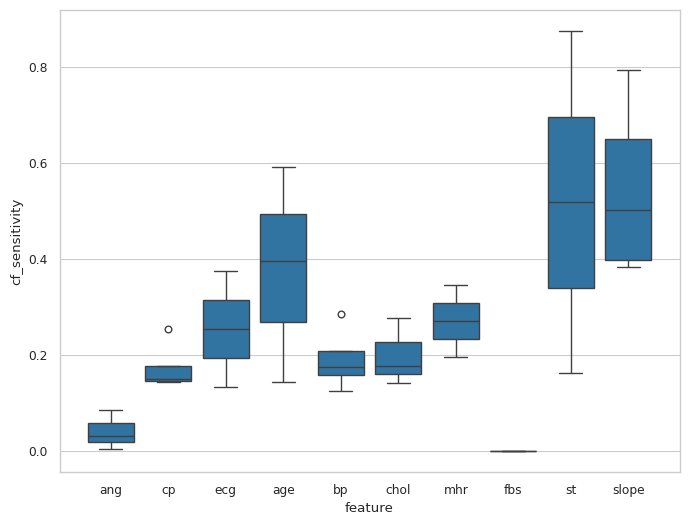

In [24]:
# Counterfactual sensitivity
f, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=sbs_results, x="feature", y="cf_sensitivity", ax=ax)

plt.plot()


# Utility vs Fairness trade-off

In [27]:
sbs_results.head()

,feature,bucket,roc_auc,ieco_mace,total_mace,cf_sensitivity,f_desc,f_corr,norm_f_desc,norm_f_corr,desc_size,u_desc_dim
0,ang,x_corr,0.772027,0.159417,0.185721,NaN,NaN,0.935394,NaN,0.870789,7,4
1,cp,x_desc,0.772027,0.159417,0.185721,0.151786,0.486667,NaN,0.000000,NaN,7,4
2,ecg,x_corr,0.772027,0.159417,0.185721,NaN,NaN,0.656364,NaN,0.025639,7,4
3,age,x_desc,0.772027,0.159417,0.185721,0.396185,0.201850,NaN,0.201850,NaN,7,4
4,bp,x_desc,0.772027,0.159417,0.185721,0.182614,0.039916,NaN,0.039916,NaN,7,4


In [34]:
baseline_roc_auc = sbs_audit_baseline['roc_auc'].values[0]
baseline_ieco_mace = sbs_audit_baseline['ieco_mace'].values[0]

print(f"Baseline ROC AUC: {baseline_roc_auc}")
print(f"Baseline IECO MACE: {baseline_ieco_mace}")

Baseline ROC AUC: 0.6407860052719866
Baseline IECO MACE: 0.09439476


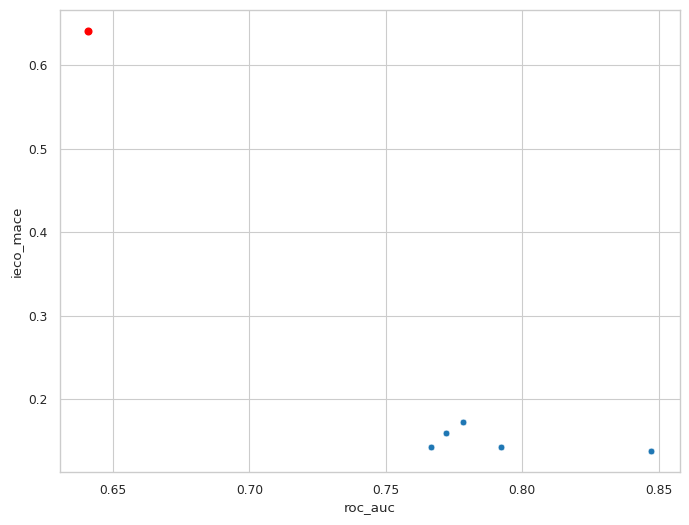

In [42]:
utility_vs_fairness = sbs_results[['roc_auc', 'ieco_mace']].drop_duplicates()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=utility_vs_fairness, x='roc_auc', y='ieco_mace', ax=ax)
ax.plot(baseline_roc_auc, baseline_roc_auc, "or")
plt.show()

### $U_{desc}$ and $U_{corr}$ utility

In [ ]:
# Average Ucorr and Udesc utility

avg_utility = sbs_results.groupby('feature')[['cf_sensitivity','norm_f_desc', 'norm_f_corr']].agg('mean').sort_values(by='cf_sensitivity', ascending=False)
avg_utility['utility_delta'] = avg_utility['norm_f_desc'] - avg_utility['norm_f_corr']
avg_utility

,cf_sensitivity,norm_f_desc,norm_f_corr,utility_delta
feature,,,,
slope,0.413177,0.371948,0.779654,-0.407706
cp,0.396205,0.201211,0.411158,-0.209947
st,0.356721,0.222663,0.748220,-0.525557
mhr,0.248859,0.194945,0.605400,-0.410455
chol,0.219958,0.088564,0.636196,-0.547632
age,0.181082,0.126853,0.652982,-0.526129
bp,0.157428,0.159466,0.566547,-0.407081
ang,0.145408,0.461917,0.758038,-0.296121
ecg,0.070536,0.153680,0.157128,-0.003448


# Bucket Assignment

What we infer from our metrics:

**Counterfactual Sensitivity (CS):** a high flip rate shows that the model has internalised a sociological pathway $S_{soc} \rightarrow X_{desc}$ where changing the sensitive attribute alters teh reconstructed feature

**Normalised $U_{desc}$ Utility:** Measures how much useful signal remains after the feature has been stripped of its relationship with $S$

**Utility Delta ($U_{desc} - U_{corr}$):** Measures the cost of $U_{desc}$ invariance by $S$. Since $U_{corr} is unconstrained, a large negative delta indicates the feature's predictive utility for the clinical outcome is inextricably tied to the sensitive attribute, and therefore has been stripped in $U_{desc}$

- **High CS (>= 0.2):**
  - **High $U_{desc}$ utility (>= 0.4):** The feature is heavily influenced by $S_{soc}$ and most of its clinical signal is preserved in $U_{desc}$ $\Rightarrow$ Assign to $X_{desc}$
  - **Low to Moderate $U_{desc}$ utility (< 0.4)** The feature is heavily influenced by $S_{soc}$, but cleaning it removes its clinical signal $\Rightarrow$ Assign to $X_{desc}$ to prioritise fairness, $X_{desc}$ to prioritise utility
    - Decision can be informed by the Utility Delta: a large negative hints at the feature's potential clinical signal to preserve
- **Low CS (< 0.2):**
  - **High $U_{corr}$ utility (>= 0.4) and large negative Utility Delta (>= -0.25):**  The feature's relationship with $S$ is likely biological ($S_{bio}$) $\Rightarrow$ Assign to $X_{corr}$
  - **Small negative Utility Delta (> -0.25):** The feature is insensitive to causal cosntraints on $S$ $\Rightarrow$ Assign to $X_{ind}$
  





In [ ]:
x_desc = []
x_corr = []
x_ind =[]
to_be_assigned = []

utility_threshold = 0.2

for feature, metrics in avg_utility.iterrows():
  if metrics["cf_sensitivity"] >= 0.2:
    if metrics["norm_f_desc"] >= utility_threshold:
      x_desc.append(feature)
    else:
      to_be_assigned.append({"feature": feature, "utility_delta": metrics['utility_delta']})
  else:
    if metrics["norm_f_corr"] >= utility_threshold and metrics['utility_delta'] <= -0.25:
      x_corr.append(feature)
    elif metrics['utility_delta'] > -0.25:
      x_ind.append(feature)
    else:
      to_be_assigned.append({"feature": feature, "utility_delta": metrics['utility_delta']})

print(f"X_desc: {x_desc}")
print(f"X_corr: {x_corr}")
print(f"X_ind: {x_ind}")
print("Remaining features to assign to X_desc or X_corr:")
print(pd.DataFrame(to_be_assigned).sort_values(by='utility_delta').to_markdown(index=False))


X_desc: ['slope', 'cp', 'st']
X_corr: ['age', 'bp', 'ang']
X_ind: ['ecg', 'fbs']
Remaining features to assign to X_desc or X_corr:
| feature   |   utility_delta |
|:----------|----------------:|
| chol      |       -0.547632 |
| mhr       |       -0.410455 |
